# Coupled Map Lattice Dynamics
### Logistic Map Based Spatiotemporal Chaos Simulation

Author: Kumar Onker  
Field: Nonlinear Dynamics / Complex Systems

## Overview

This project explores the rich spatiotemporal dynamics of **Coupled Map Lattices (CMLs)** and network-coupled oscillators. By implementing various local nonlinear models and coupling topologies, we investigate the emergence of spatiotemporal chaos, pattern formation, and partial synchronization in high-dimensional systems.

Coupled map lattices serve as an excellent paradigm for studying extended dynamical systems, bridging the gap between discrete cellular automata and continuous partial differential equations.

**Key dynamical systems and phenomena explored in this notebook include:**

1. **Logistic Map CMLs:** Investigating baseline spatiotemporal chaos, bifurcation diagrams, and fundamental spatial diffusive coupling dynamics.
2. **3D Rössler Coupled Map Lattice:** Extending the system to a 3-dimensional spatial grid (a 3-torus). We use the continuous-time chaotic Rössler attractor as the local dynamical node to observe propagating wavefronts, spatial synchronization, and defect-mediated turbulence.
3. **Chimera States in Phase Oscillators:** Simulating globally coupled discrete-time phase oscillators to observe the spontaneous breaking of spatial symmetry. This leads to the fascinating "Chimera State"—the simultaneous coexistence of coherent (synchronized) and incoherent (desynchronized) domains within a network of identical oscillators.

**Techniques Highlighted:**
Numerical integration (Runge-Kutta 4th Order), network dynamics modeling, multi-dimensional array manipulation, and advanced spatiotemporal data visualization.

# **Bifurcation Graph**

## Mathematical Model

The coupled map lattice evolves according to:

$$x_i(t+1) = (1 - ε) f(x_i(t)) + (ε/2)[f(x_{i-1}(t)) + f(x_{i+1}(t))]$$

where

$$f(x) = r x (1 - x)$$

Here:

r = logistic map parameter  
ε = coupling strength  
i = lattice site index

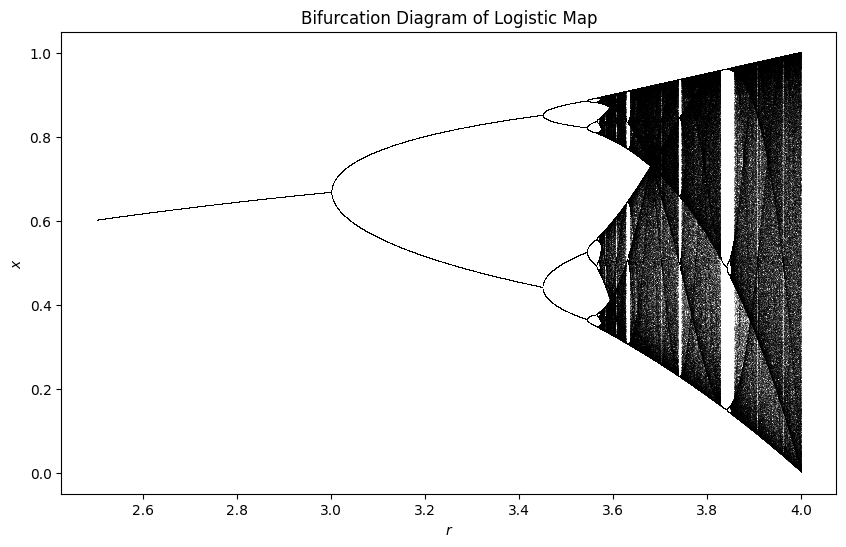

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Logistic map function
def logistic_map(x, r):
    return r * x * (1 - x) 

# Bifurcation diagram
def plot_bifurcation(r_min=2.5, r_max=4.0, num_points=5000, iterations=5000, last=500):
    r_values = np.linspace(r_min, r_max, num_points)
    x = 1e-4 * np.ones(num_points)  # Initial condition
    bifurcation_r = []
    bifurcation_x = []

    for _ in range(iterations):
        x = logistic_map(x, r_values)
        if _ >= (iterations - last):  # Collect points for the last few iterations
            bifurcation_r.extend(r_values)
            bifurcation_x.extend(x)

    plt.figure(figsize=(10, 6))
    plt.plot(bifurcation_r, bifurcation_x, ',k', alpha=0.25)
    plt.title("Bifurcation Diagram of Logistic Map")
    plt.xlabel("$r$")
    plt.ylabel("$x$")
    plt.show()

# Plot the bifurcation diagram
plot_bifurcation()



# Fixed Space and time

    Simulates a Coupled Map Lattice with fixed space and fixed time.

    Parameters:
    - space_size (int): Number of spatial points (size of the lattice).
    - time_steps (int): Number of time steps to simulate.
    - coupling_constant (float): Determines the coupling strength between neighboring cells.
    - map_function (callable): The local map function for individual cells (e.g., logistic map).
    - initial_conditions (array-like, optional): Initial conditions for the lattice.
      If None, random initial conditions are generated.

    Returns:
    - lattice (ndarray): The resulting lattice after simulation.

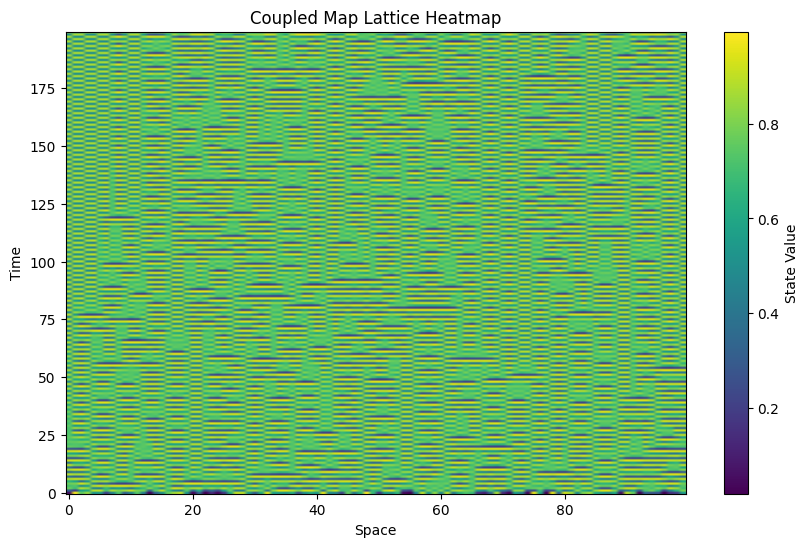

In [14]:
# Simulates a Coupled Map Lattice.

def coupled_map_lattice(space_size, time_steps, coupling_constant, map_function, initial_conditions=None):
    if initial_conditions is None:
        # Initialize the lattice with random values in [0, 1]
        lattice = np.random.rand(time_steps, space_size)
    else:
        lattice = np.zeros((time_steps, space_size))
        lattice[0] = initial_conditions

    for t in range(time_steps - 1):
        for i in range(space_size):
            # Coupling with periodic boundary conditions
            left = lattice[t, (i - 1) % space_size]
            right = lattice[t, (i + 1) % space_size]
            current = lattice[t, i]

            # Apply the coupled map equation
            lattice[t + 1, i] = (1 - coupling_constant) * map_function(current) + \
                                (coupling_constant / 2) * (map_function(left) + map_function(right))

    return lattice

# Example usage
def logistic_map(x, r=3.8):
    """Logistic map function."""
    return r * x * (1 - x)

# Parameters
space_size = 100  # Number of spatial points
time_steps = 200  # Number of time steps
coupling_constant = 0.3  # Coupling constant
initial_conditions = np.random.rand(space_size)  # Random initial conditions

# Simulate
lattice = coupled_map_lattice(space_size, time_steps, coupling_constant, logistic_map, initial_conditions)

# Visualization: Heatmap
plt.figure(figsize=(10, 6))
plt.imshow(lattice, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar(label='State Value')
plt.title("Coupled Map Lattice Heatmap")
plt.xlabel("Space")
plt.ylabel("Time")
plt.show()


## 1. 3D Coupled Map Lattice (CML) with Rössler Dynamics

In this section, we simulate a 3D spatiotemporal system using a Coupled Map Lattice (CML). Instead of a simple discrete map, the local dynamics at each node are governed by the continuous-time **Rössler attractor**, known for its continuous chaos and topological simplicity. 

### Mathematical Formulation

**1. Local Nonlinear Dynamics (Rössler System):**
The Rössler system is described by three coupled ordinary differential equations (ODEs). For a given node, the state $\mathbf{u} = (x, y, z)$ evolves according to:
$$\frac{dx}{dt} = -y - z$$
$$\frac{dy}{dt} = x + a y$$
$$\frac{dz}{dt} = b + z(x - c)$$
Where $a, b,$ and $c$ are the system parameters. These ODEs are numerically integrated over a time step $dt$ using the Runge-Kutta 4th Order (RK45) method to serve as the local map $\mathcal{F}(\mathbf{u})$.

**2. Spatial Coupling Topology:**
The system is arranged on a 3D lattice with periodic boundary conditions (a 3-torus). Each node $(i, j, k)$ is diffusively coupled to its 6 nearest neighbors (top, bottom, left, right, front, back). The state update rule is given by:
$$\mathbf{u}_{i,j,k}^{t+1} = (1 - \epsilon) \mathcal{F}(\mathbf{u}_{i,j,k}^t) + \frac{\epsilon}{6} \sum_{n \in \mathcal{N}} \mathbf{u}_{n}^t$$
where $\epsilon$ is the coupling strength and $\mathcal{N}$ represents the 6 nearest neighbors.

### Simulation Details
- **Lattice Size**: $10 \times 10 \times 10$
- **Parameters**: $a = 0.2, b = 0.2, c = 5.7$ (Standard chaotic regime for Rössler)
- **Coupling Strength ($\epsilon$)**: $0.1$

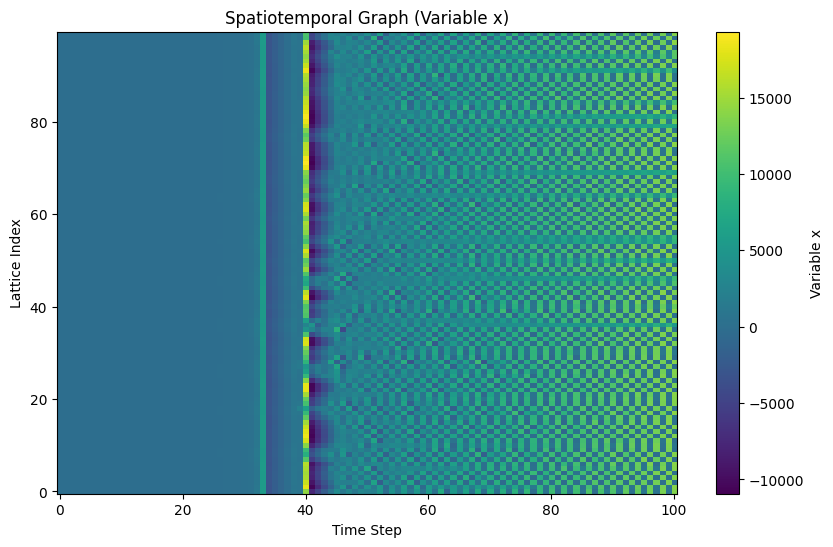

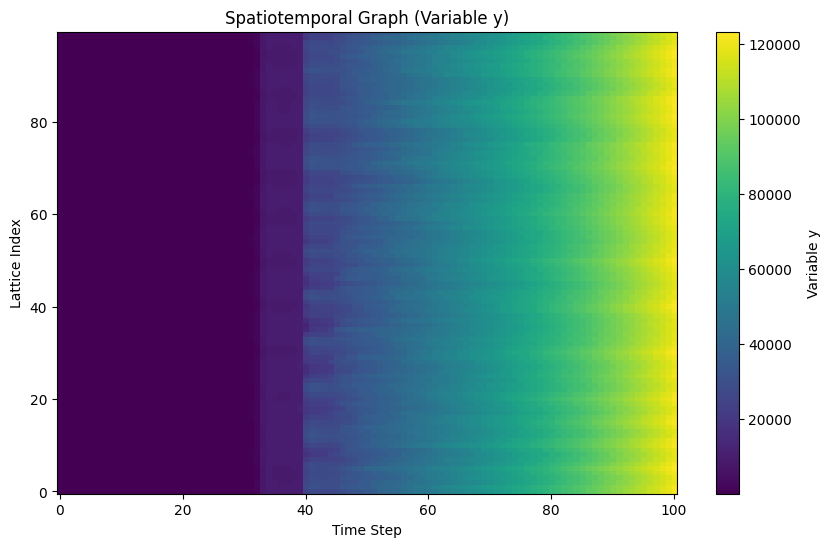

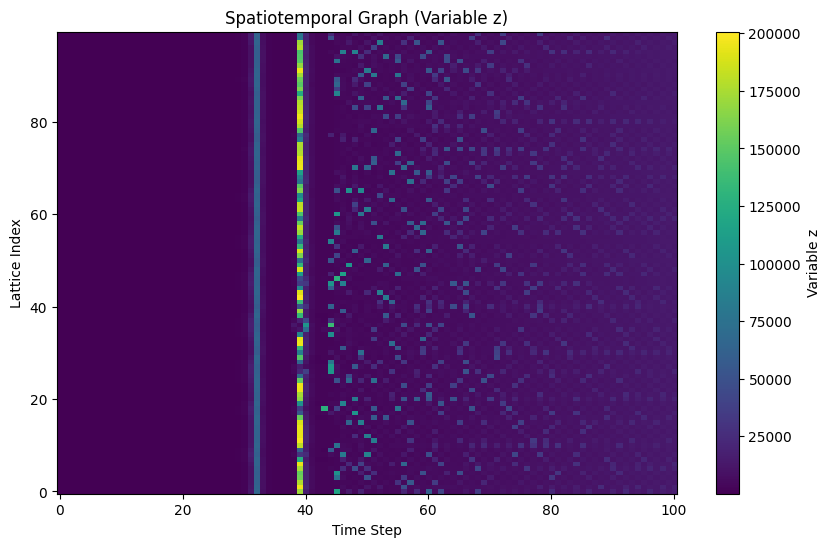

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def rossler_system(t, state, a, b, c):
    """Rössler system equations."""
    x, y, z = state
    dxdt = -y - z
    dydt = x + a * y
    dzdt = b + z * (x - c)
    return [dxdt, dydt, dzdt]

def update_rossler_site(state, dt, a, b, c):
    """Update a single Rössler attractor state using numerical integration."""
    sol = solve_ivp(rossler_system, [0, dt], state, args=(a, b, c), method='RK45')
    return sol.y[:, -1]

def update_cml(lattice, coupling, dt, a, b, c, size):
    """Update the 3D Coupled Map Lattice for one time step."""
    new_lattice = np.zeros_like(lattice)
    for i in range(size):
        for j in range(size):
            for k in range(size):
                # Update the current site using the Rössler attractor
                local_update = update_rossler_site(lattice[i, j, k], dt, a, b, c)

                # Sum the neighbors' contributions
                neighbors_sum = (
                    lattice[(i-1) % size, j, k] + lattice[(i+1) % size, j, k] +
                    lattice[i, (j-1) % size, k] + lattice[i, (j+1) % size, k] +
                    lattice[i, j, (k-1) % size] + lattice[i, j, (k+1) % size]
                )

                # Apply the coupling (average neighbor influence)
                new_lattice[i, j, k] = (1 - coupling) * local_update + (coupling / 6) * np.sum(neighbors_sum, axis=0)
    return new_lattice

def simulate_cml(size, coupling, dt, a, b, c, steps):
    """Simulate the 3D Coupled Map Lattice."""
    # Initialize lattice with random Rössler states
    lattice = np.random.rand(size, size, size, 3)
    history = [lattice]
    for _ in range(steps):
        lattice = update_cml(lattice, coupling, dt, a, b, c, size)
        history.append(lattice)
    return history

def create_spatiotemporal_graph(history, size, variable_index=0):
    """
    Create a spatiotemporal graph for a fixed spatial slice.

    Parameters:
    - history: List of 3D lattices over time.
    - size: Size of the lattice.
    - variable_index: Index of the variable to visualize (0=x, 1=y, 2=z).
    """
    spatiotemporal_data = []
    for lattice in history:
        slice_data = lattice[:, :, size // 2, variable_index]
        spatiotemporal_data.append(slice_data.flatten())

    spatiotemporal_data = np.array(spatiotemporal_data)

    # Plot spatiotemporal graph
    plt.figure(figsize=(10, 6))
    plt.imshow(spatiotemporal_data.T, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(label=f"Variable {['x', 'y', 'z'][variable_index]}")
    plt.xlabel("Time Step")
    plt.ylabel("Lattice Index")
    plt.title(f"Spatiotemporal Graph (Variable {['x', 'y', 'z'][variable_index]})")
    plt.show()

# Parameters
size = 10        # Lattice size (10x10x10)
coupling = 0.1   # Coupling strength
dt = 0.01        # Time step for Rössler updates
a = 0.2          # Rössler parameter
b = 0.2          # Rössler parameter
c = 5.7          # Rössler parameter
steps = 100      # Number of time steps

# Simulation
history = simulate_cml(size, coupling, dt, a, b, c, steps)

# Spatiotemporal Graph for the x-variable
create_spatiotemporal_graph(history, size, variable_index=0)

create_spatiotemporal_graph(history, size, variable_index=1)

create_spatiotemporal_graph(history, size, variable_index=2)


### Output Analysis: Spatiotemporal Graphs
The output graphs display the **spatiotemporal evolution** of the network for the individual state variables ($x, y$, and $z$). 

Because visualizing a dynamic 3D grid directly is complex, we extract a 2D spatial slice from the middle of the lattice ($z = \text{size}//2$) and flatten it into a 1D array. 
- **Y-axis (Lattice Index):** Represents the flattened spatial nodes of the 2D slice.
- **X-axis (Time Step):** Represents the evolution of time.
- **Color scale:** Indicates the amplitude of the chosen variable.

By observing these plots, we can identify propagating wavefronts, spatial synchronization, and defect-mediated turbulence characteristic of coupled chaotic oscillators.

## 2. Chimera States in Globally Coupled Phase Oscillators

This section explores the phenomenon of **Chimera States**—a fascinating dynamical state where a network of identical, symmetrically coupled oscillators spontaneously splits into two distinct domains: one highly synchronized (coherent) and the other desynchronized (incoherent). 

### Mathematical Formulation

We use a discrete-time phase oscillator model inspired by the Kuramoto model. The state of the network is defined by the phases $\theta_i \in [0, 2\pi)$ of $N$ oscillators.

**Update Equation:**
The phase evolution of the $i$-th oscillator is governed by:
$$\theta_i(t+1) = \left( \theta_i(t) + \omega + \frac{\sigma}{N} \sum_{j=1}^{N} \sin(\theta_j(t) - \theta_i(t)) \right) \mod 2\pi$$
Where:
- $\omega$ (represented as `r` in the code) is the intrinsic frequency parameter.
- $\sigma$ is the global coupling strength.
- The coupling is **all-to-all (global)**, meaning every oscillator interacts with the mean field of the entire network.

By carefully tuning $\omega$ and $\sigma$, the symmetry of the system breaks, leading to the emergence of chimera states.

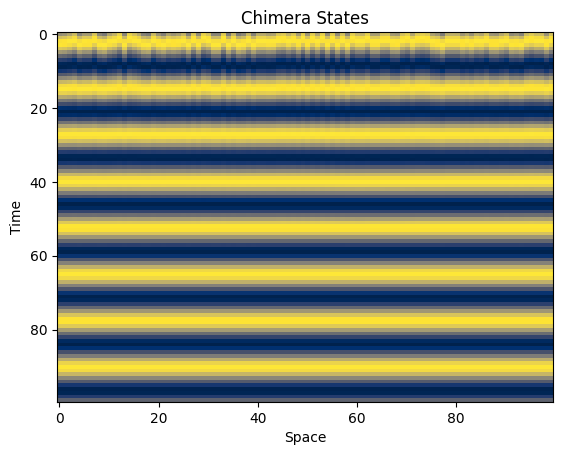

In [19]:
def chimera_states(n, timesteps, r, sigma):
    lattice = np.random.rand(timesteps, n)
    for t in range(timesteps - 1):
        for i in range(n):
            sum_neighbors = sum(np.sin(lattice[t, j] - lattice[t, i]) for j in range(n)) / n
            lattice[t + 1, i] = (lattice[t, i] + r + sigma * sum_neighbors) % (2 * np.pi)
    return lattice

# Parameters
n = 100
timesteps = 100
r, sigma = 0.5, 0.1

lattice = chimera_states(n, timesteps, r, sigma)

plt.imshow(np.sin(lattice), cmap='cividis', aspect='auto')
plt.title("Chimera States")
plt.xlabel("Space")
plt.ylabel("Time")
plt.show()


### Output Analysis: Chimera State Heatmap
The generated heatmap visualizes the sine of the phases, $\sin(\theta_i(t))$, across space and time.
- **X-axis (Time):** The temporal evolution of the system.
- **Y-axis (Space):** The indices of the oscillators in the 1D network.

**Interpreting the Graph:**
- **Coherent Regions:** Areas where the color bands are smooth and uniform indicate synchronized oscillators moving together.
- **Incoherent Regions:** Areas with static-like, noisy, or rapidly fluctuating color gradients represent the desynchronized oscillators.
The simultaneous coexistence of these smooth and noisy spatial bands confirms the successful generation of a discrete-time Chimera state.